# CCO12: Relabel CCO10

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import ListedColormap
import anndata as ad
import seaborn as sns
import matplotlib as mpl
import tqdm

In [2]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO12"
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO10"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")
os.system(f"mkdir -p {WORK_DIR}/umap")
os.system(f"mkdir -p {WORK_DIR}/dotplot")
os.system(f"mkdir -p {WORK_DIR}/distribution")

0

In [4]:
# colormap = {
#     "CM": (60/255, 170/255, 60/255),
#     "EC": (230/255, 80/255, 160/255),
#     "MP": (141/255, 160/255, 203/255),
#     "PC": (255/255, 235/255, 125/255),
#     "CF": (240/255, 180/255, 20/255),
#     "VSMC": (220/255, 160/255, 30/255),
#     "OT": (190/255, 190/255, 190/255),
#     "OTH": (170/255, 170/255, 170/255),
# }

colormap = {
    "CM": (43/255, 119/255, 56/255),
    "EC": (231/255, 76/255, 60/255),
    "MP": (255/255, 240/255, 178/255),
    "PC": (218/255, 150/255, 18/255),
    "CF": (142/255, 150/255, 45/255),
    "VSMC": (165/255, 125/255, 8/255),
    "OTH": (191/255, 200/255, 201/255),
    "MP+PC+VSMC": (213/255, 172/255, 68/255),
}

colormap_subclusters = {
    "CM_1": (43/255, 119/255, 56/255, ),
    "CM_2": (113/255, 181/255, 113/255, ),
    "CM_3": (30/255, 96/255, 45/255, ),
    "CM_4": (87/255, 159/255, 87/255, ),
    "CM_5": (174/255, 211/255, 161/255, ),
    "CM_6": (223/255, 239/255, 218/255, ),
    
    "EC_1": (255/255, 200/255, 230/255),
    "EC_2": (230/255, 80/255, 160/255),
    "EC_3": (180/255, 30/255, 120/255),
    
    "PVSC_1": (255/255, 250/255, 200/255),
    "PVSC_2": (255/255, 245/255, 175/255),
    "PVSC_3": (255/255, 240/255, 150/255),
    "PVSC_4": (255/255, 235/255, 125/255),
    "PVSC_5": (255/255, 230/255, 100/255),
    "PVSC_6": (255/255, 220/255, 75/255),
    "PVSC_7": (255/255, 210/255, 50/255),
    "PVSC_8": (255/255, 200/255, 25/255),
    "PVSC_9": (240/255, 180/255, 10/255),
    "PVSC_10": (220/255, 160/255, 0/255),

    "EP": (141/255, 160/255, 203/255),

    "UN": (190/255, 190/255, 190/255),
}

colormap_leiden = {
    0: (62/255, 139/255, 69/255),
    1: (87/255, 159/255, 87/255),
    2: (38/255, 128/255, 66/255),
    3: (238/255, 201/255, 52/255),
    4: (231/255, 76/255, 60/255),
    5: (224/255, 181/255, 18/255),
    6: (43/255, 119/255, 56/255),
    7: (255/255, 226/255, 150/255),
    8: (255/255, 240/255, 178/255),
    9: (218/255, 150/255, 18/255),
    10: (174/255, 211/255, 161/255),
    11: (113/255, 181/255, 113/255),
    12: (252/255, 211/255, 128/255),
    13: (142/255, 150/255, 45/255),
    14: (30/255, 96/255, 45/255),
    15: (206/255, 231/255, 188/255),
    16: (145/255, 196/255, 137/255),
    17: (223/255, 239/255, 218/255),
    18: (191/255, 200/255, 201/255),
    19: (165/255, 125/255, 8/255),
}

samples = ['ALL', 'VO', 'HO', 'ReAgg-CM', 'Fus-HO', 'VasHO']
samples_old = ['ALL','VO','HO','CA','VHO','VCO']
sample_mapper = {"VO": "VO", "HO": "HO", "CA": "ReAgg-CM", "VHO": "Fus-HO", "VCO": "VasHO"}

cell_types = ['CM', 'PC', 'EC', 'MP', 'CF', 'VSMC', 'OTH']

# 1. Relabel celltype

## 1.1 label

In [5]:
adata_all = sc.read_h5ad(f"{PREV_DIR}/adata/cell_type_labelled/ALL.h5ad")

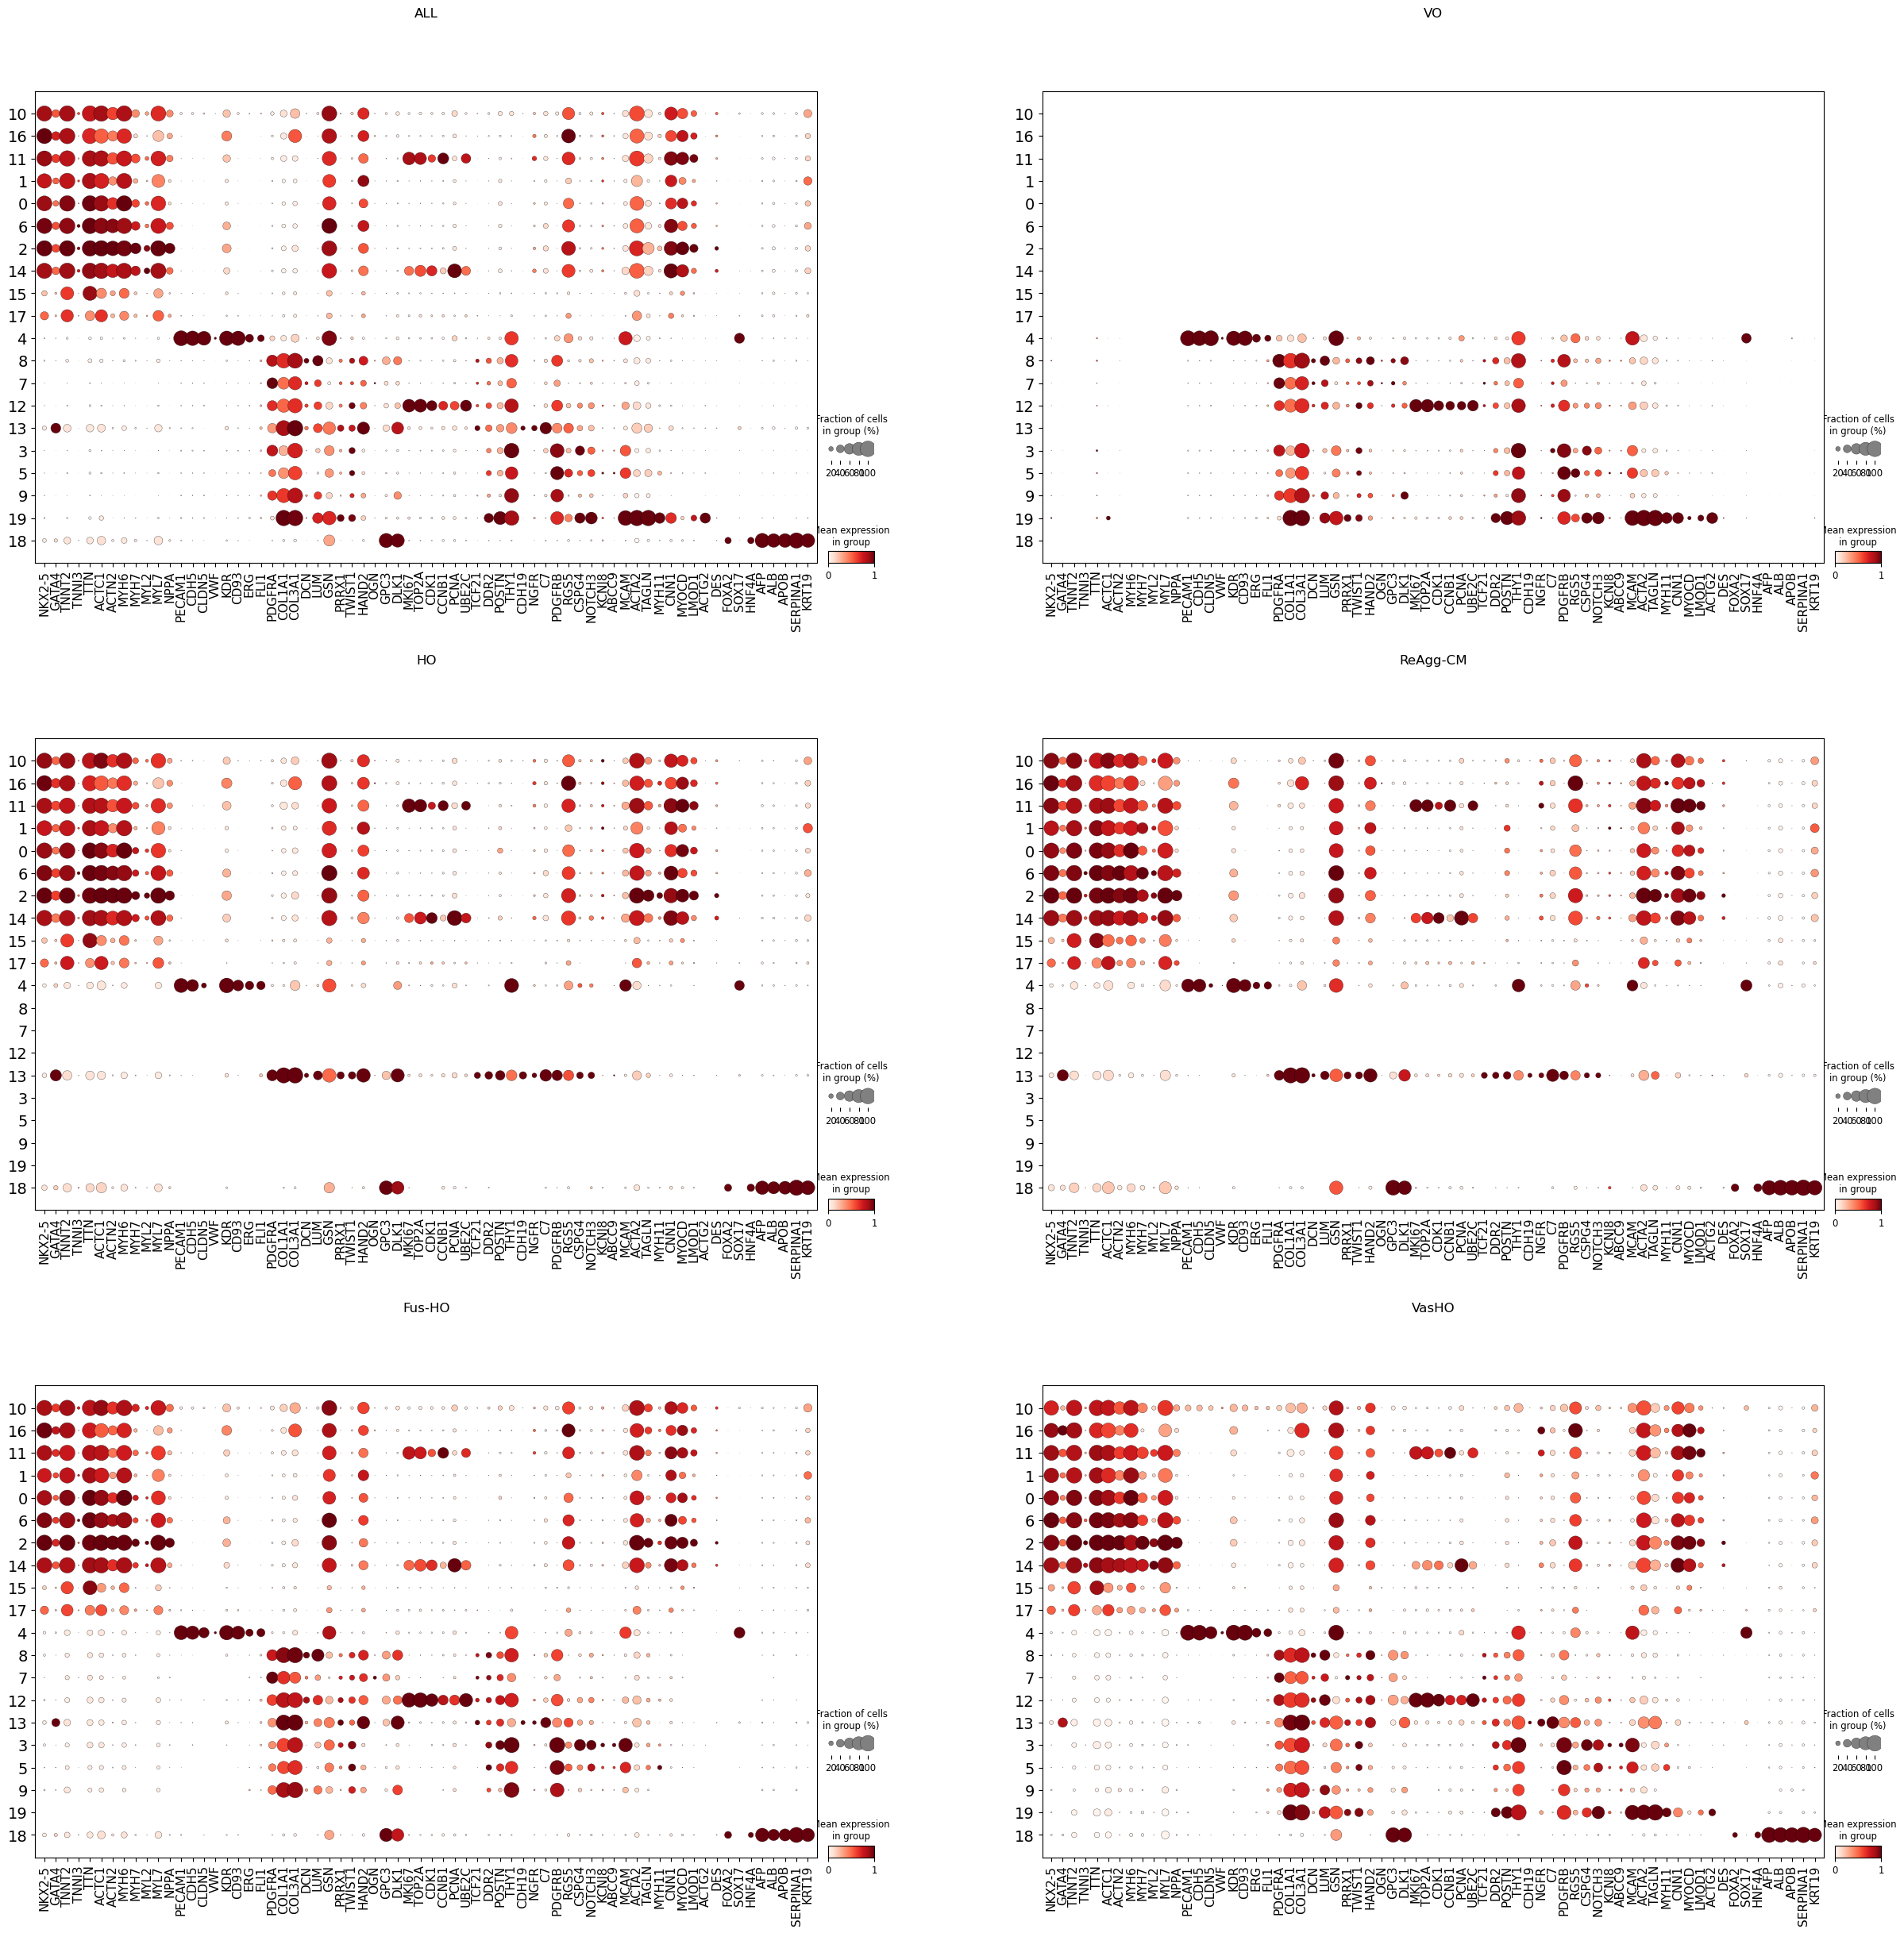

In [24]:
import warnings
warnings.filterwarnings("ignore")

MIN_COUNT = 20

fig, axs = plt.subplots(3, 2, figsize=(30,30), layout="constrained")
axs = axs.flatten()

marker_dict = [
    "NKX2-5", "GATA4", "TNNT2", "TNNI3", "TTN", "ACTC1", "ACTN2", "MYH6", "MYH7", "MYL2", "MYL7", "NPPA",
    "PECAM1", "CDH5", "CLDN5", "VWF", "KDR", "CD93", "ERG", "FLI1",
    "PDGFRA", "COL1A1", "COL3A1", "DCN", "LUM", "GSN", "PRRX1", "TWIST1", "HAND2", "OGN", "GPC3", "DLK1",
    "MKI67", "TOP2A", "CDK1", "CCNB1", "PCNA", "UBE2C",
    "TCF21", "DDR2", "POSTN", "THY1", "CDH19", "NGFR", "C7", 
    "PDGFRB", "RGS5", "CSPG4", "NOTCH3", "KCNJ8", "ABCC9", "MCAM",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "MYOCD", "LMOD1", "ACTG2", "DES",
    "FOXA2", "SOX17", "HNF4A", "AFP", "ALB", "APOB", "SERPINA1", "KRT19",
]

cluster_order = [10, 16, 11, 1, 0, 6, 2, 14, 15, 17, 4, 8, 7, 12, 13, 3, 5, 9, 19, 18]

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).sum() >= MIN_COUNT:
            continue
        elif (adata.obs['leiden'] == j).any():
            adata.X[adata.obs['leiden'] == j, :] = 0;
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    dp = sc.pl.dotplot(adata, 
                       marker_dict, 
                       categories_order=cluster_order,
                       groupby="leiden", 
                       standard_scale="var", 
                       ax=axs[i], 
                       title=sample, 
                       show=False)
    dp['mainplot_ax'].tick_params(axis="x", labelsize=11)
    dp['mainplot_ax'].tick_params(axis="y", labelsize=14)
    
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.png')
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.complete.svg')
plt.show()

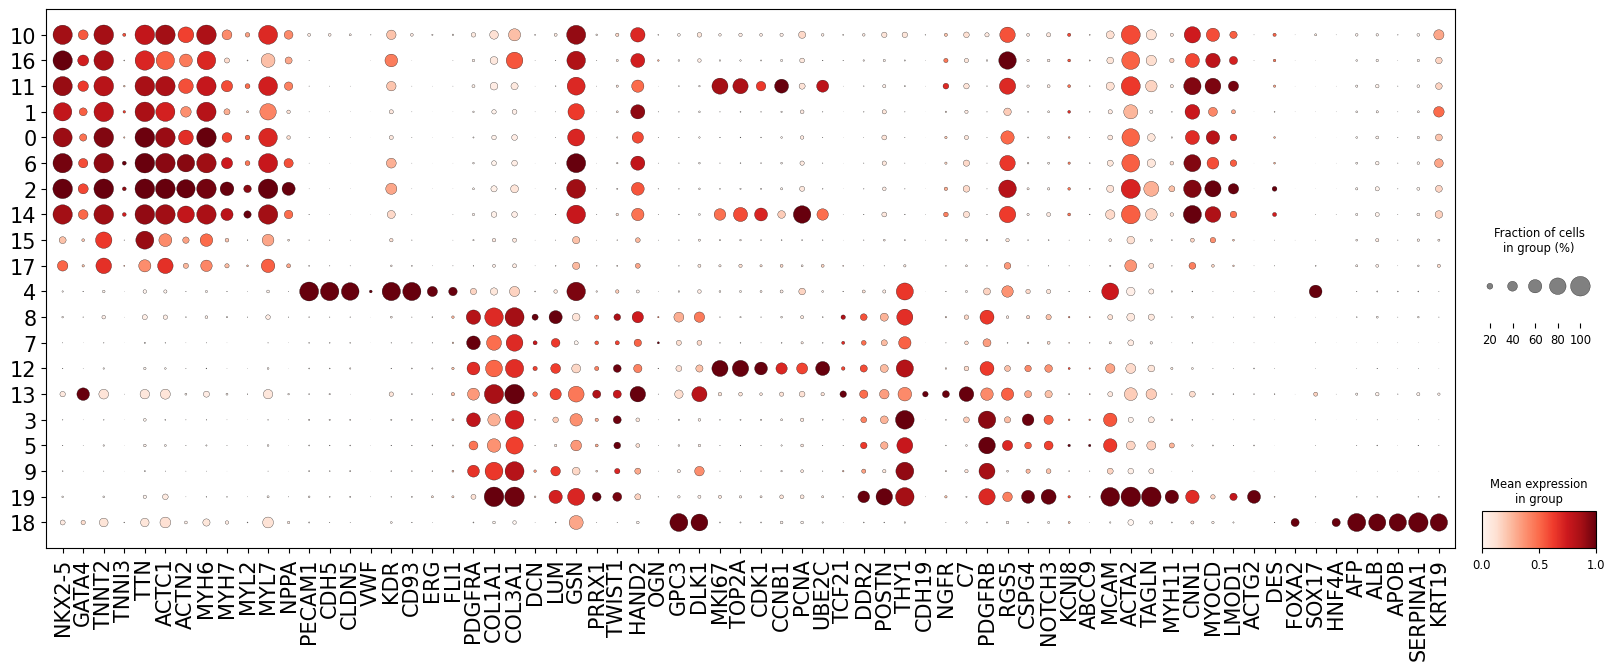

In [7]:
# fig, ax = plt.subplots(1, 1, figsize=(24, 8))
# sc.pl.dotplot(adata_all,
#              marker_dict,
#              categories_order=cluster_order,
#              groupby="leiden",
#              standard_scale="var",
#              ax=ax,
#              show=False)

dp = sc.pl.dotplot(
    adata_all,
    marker_dict,
    categories_order=cluster_order,
    groupby="leiden",
    standard_scale="var",
    return_fig=True,
    show=False,
    figsize=(20,7)
)

dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=15)

plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.all.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/original_laiden.all.svg', bbox_inches="tight")
plt.show()

In [34]:
celltypes_dict = {
    0: 'CM',
    1: 'CM',
    2: 'CM',
    3: 'PC',
    4: 'EC',
    5: 'PC',
    6: 'CM',
    7: 'MP',
    8: 'MP',
    9: 'PC',
    10: 'CM',
    11: 'CM',
    12: 'MP',
    13: 'CF',
    14: 'CM',
    15: 'CM',
    16: 'CM',
    17: 'CM',
    18: 'OTH',
    19: 'VSMC',
}

adata_all.obs['cell_type'] = adata_all.obs['leiden'].map(celltypes_dict)
adata_all.obs['cell_type'] = adata_all.obs['cell_type'].astype("category")

adata_all.obs['batch_old'] = adata_all.obs['batch'].copy()
adata_all.obs['batch'] = adata_all.obs['batch_old'].map(sample_mapper)
adata_all.obs['batch'] = adata_all.obs['batch'].astype("category")

In [35]:
adata_all.var.drop(columns=['n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'highly_variable-2', 'means-2', 'dispersions-2', 'dispersions_norm-2', 'n_cells_by_counts-3', 'mean_counts-3', 'log1p_mean_counts-3', 'pct_dropout_by_counts-3', 'total_counts-3', 'log1p_total_counts-3', 'highly_variable-3', 'means-3', 'dispersions-3', 'dispersions_norm-3', 'n_cells_by_counts-4', 'mean_counts-4', 'log1p_mean_counts-4', 'pct_dropout_by_counts-4', 'total_counts-4', 'log1p_total_counts-4', 'highly_variable-4', 'means-4', 'dispersions-4', 'dispersions_norm-4'], inplace=True)

os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_labelled")
adata_all.write(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for group in adata_all.obs["batch"].unique():
    adata_all[adata_all.obs["batch"] == group].write(f"{WORK_DIR}/adata/cell_type_labelled/{group}.h5ad")

os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_split")
for ct in adata_all.obs["cell_type"].unique():
    adata_all[adata_all.obs["cell_type"] == ct].write(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

## 1.2 visualization

In [70]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")

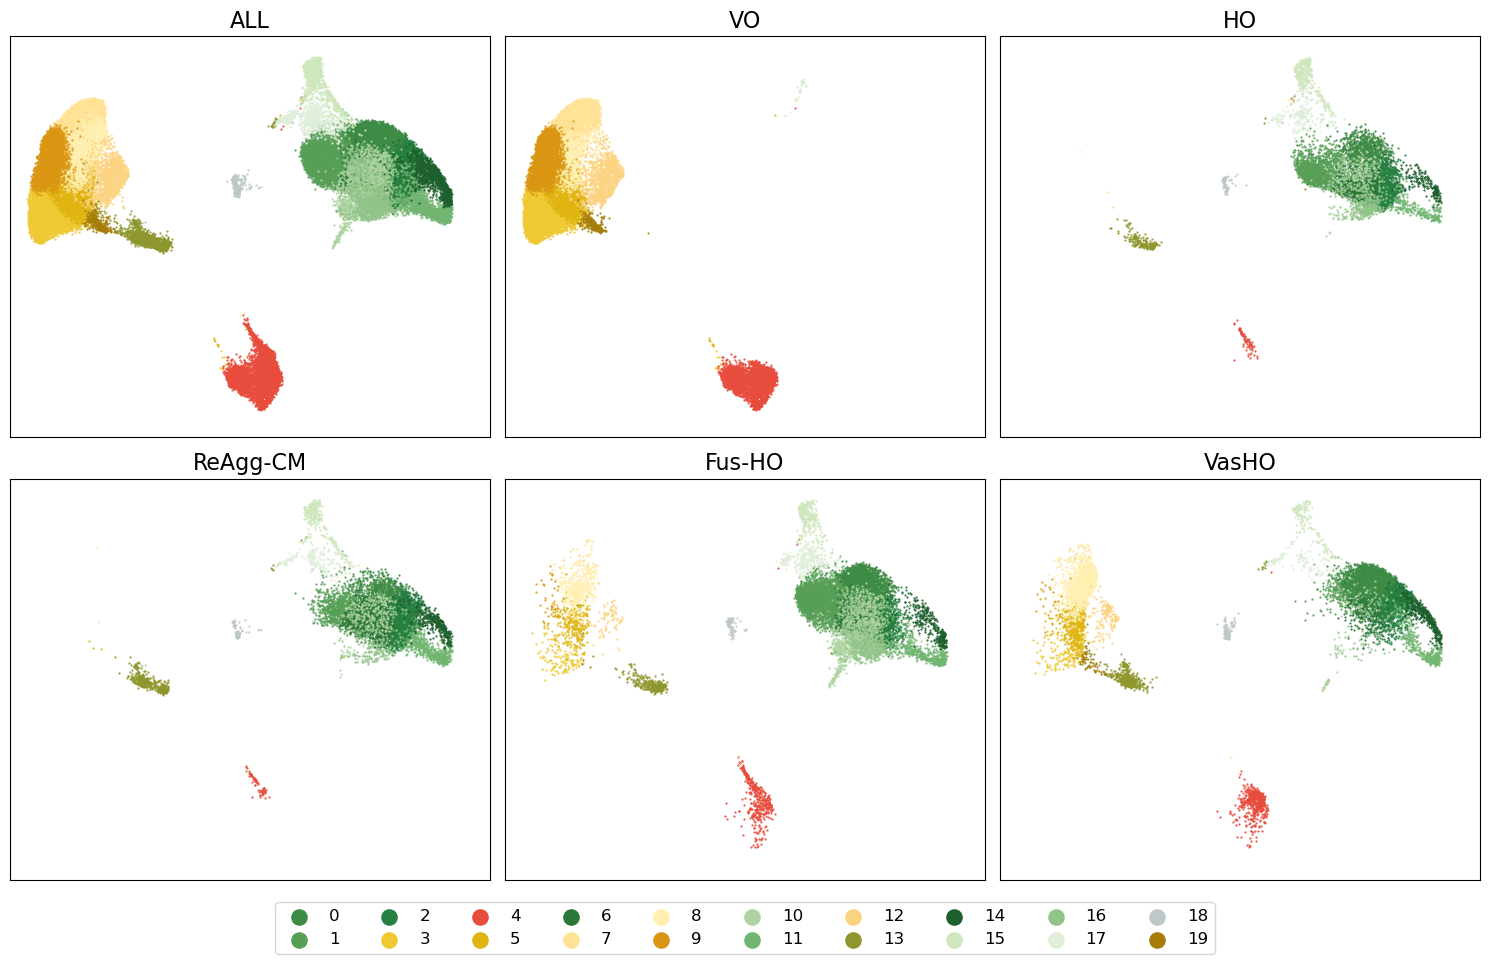

In [71]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples[i]]
    
    for ld in range(0, 20):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 1], 
            label=ld, 
            color=colormap_leiden[ld], 
            s=0.3, 
            alpha=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample, fontsize=16)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=20,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umap/original_leiden.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umap/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

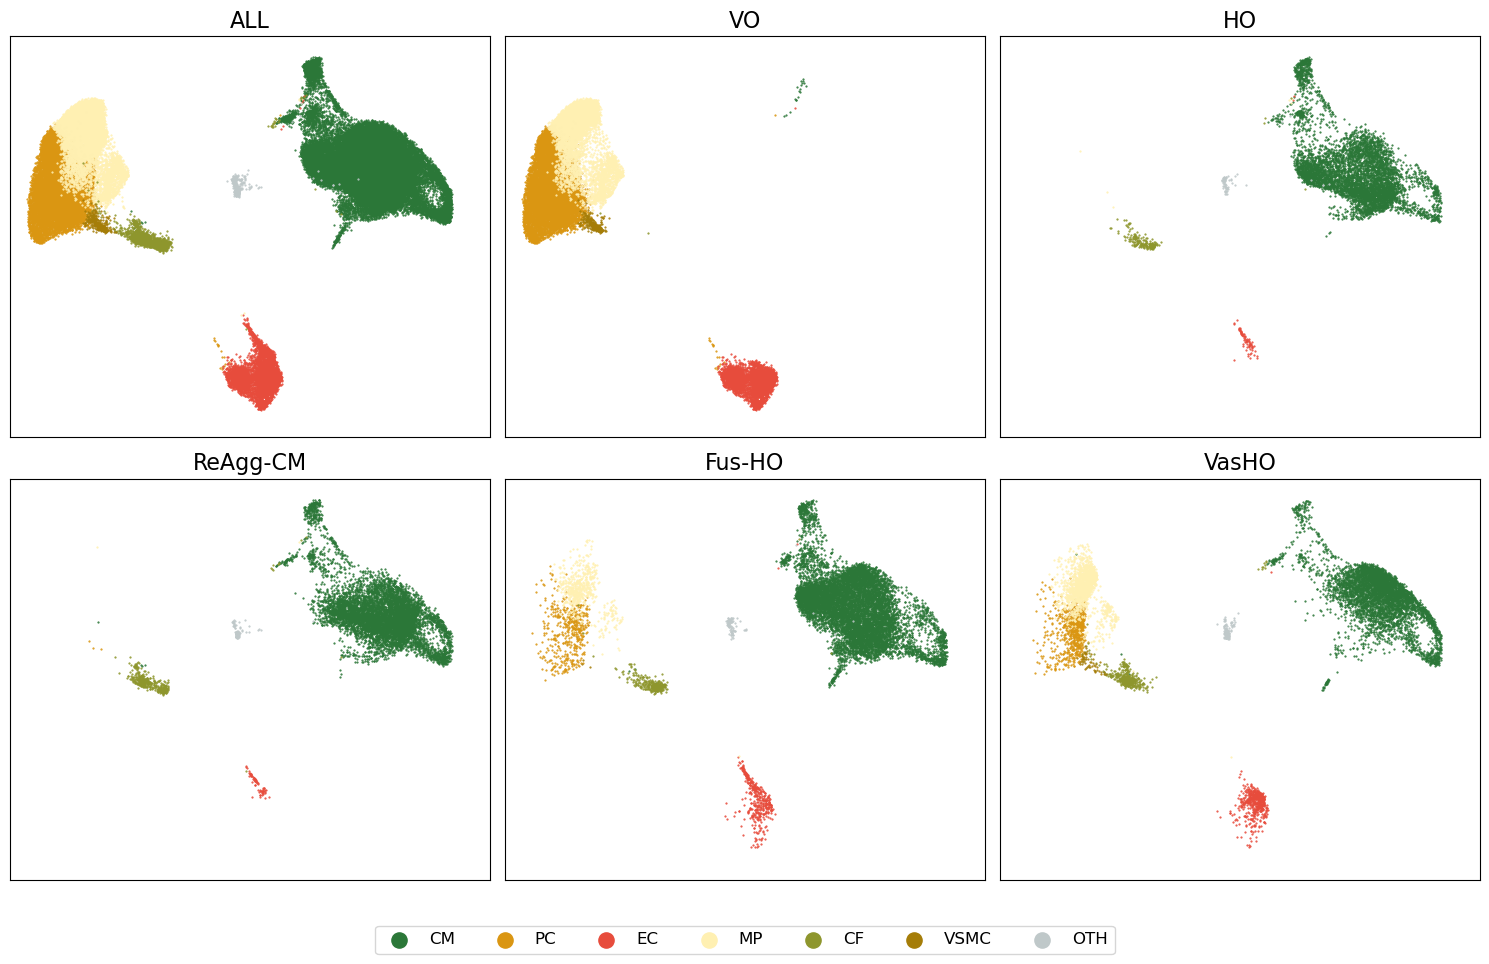

In [72]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples[i]]
    
    for j, ld in enumerate(cell_types):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ld, 1], 
            label=ld, 
            color=colormap[ld], 
            s=0.3, 
            alpha=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample, fontsize=16)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=20,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umap/cell_type.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umap/cell_type.complete.svg', bbox_inches="tight")
plt.show()

In [73]:
res = {"batch": [], "cell_type": [], "count": []}

for sample, sample_old in zip(samples, samples_old):
    if sample == "ALL":
        continue
    adata = adata_all[adata_all.obs["batch"] == sample]
    # res[sample] = []
    for ct in cell_types:
        res["batch"].append(sample)
        res["cell_type"].append(ct)
        res["count"].append((adata.obs["cell_type"] == ct).sum())

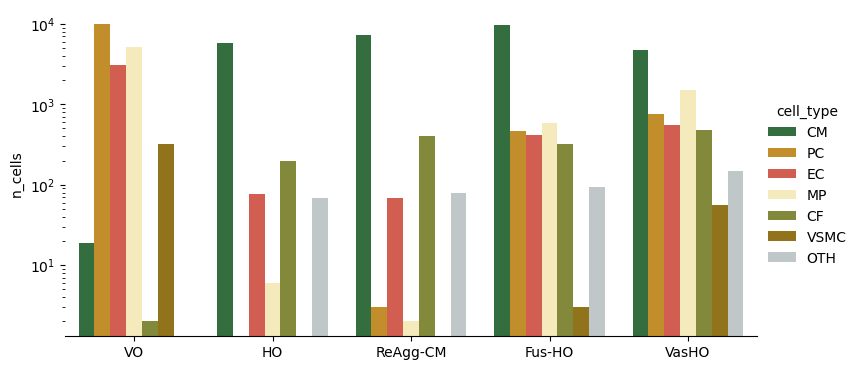

In [74]:
g = sns.catplot(
    data=pd.DataFrame(res), 
    kind="bar",
    x="batch", 
    y="count", 
    hue="cell_type",
    palette=colormap, 
    alpha=1.0, 
    height=4, aspect=2
)
g.despine(left=True)
for ax in g.axes.flat:
    ax.set_yscale("log")
g.set_axis_labels("", "n_cells")

plt.savefig(f"{WORK_DIR}/distribution/batch.full.n_cell.png")
plt.savefig(f"{WORK_DIR}/distribution/batch.full.n_cell.svg")
plt.show()

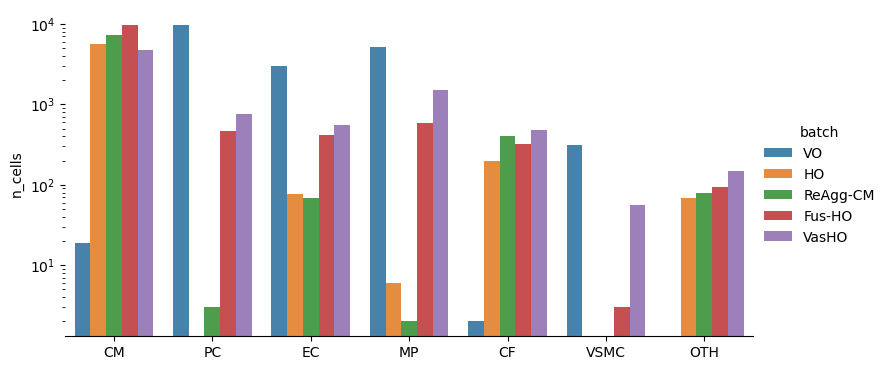

In [75]:
g = sns.catplot(
    data=pd.DataFrame(res), 
    kind="bar",
    x="cell_type", 
    y="count", 
    hue="batch",
    # palette=colormap, 
    alpha=.9, 
    height=4, aspect=2
)
g.despine(left=True)
for ax in g.axes.flat:
    ax.set_yscale("log")
g.set_axis_labels("", "n_cells")

plt.savefig(f"{WORK_DIR}/distribution/cell_type.full.n_cell.png")
plt.savefig(f"{WORK_DIR}/distribution/cell_type.full.n_cell.svg")
plt.show()

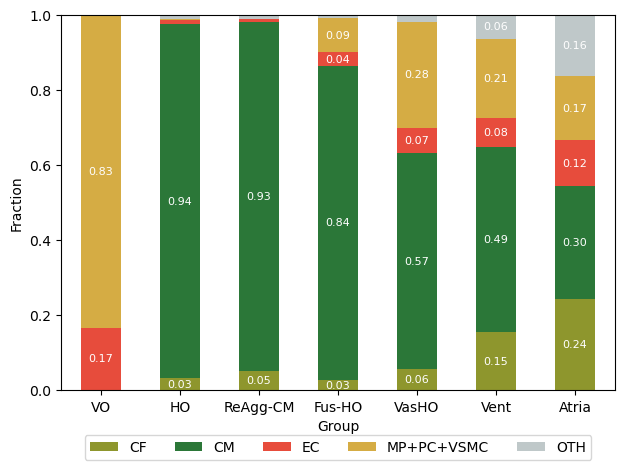

In [78]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata_all[adata_all.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T

df["Vent"] = df["VO"].copy()
df.loc["CM", "Vent"] = 49.2
df.loc["EC", "Vent"] = 7.8
df.loc["CF", "Vent"] = 15.5
df.loc["PC", "Vent"] = 21.2
df.loc["VSMC", "Vent"] = 0
df.loc["MP", "Vent"] = 0
df.loc["OTH", "Vent"] = 6.3

df["Atria"] = df["Vent"].copy()
df.loc["CM", "Atria"] = 30.1
df.loc["EC", "Atria"] = 12.2
df.loc["CF", "Atria"] = 24.3
df.loc["PC", "Atria"] = 17.1
df.loc["VSMC", "Atria"] = 0
df.loc["MP", "Atria"] = 0
df.loc["OTH", "Atria"] = 16.3

df = np.divide(df, df.sum())
df = df.T

df["MP+PC+VSMC"] = df["MP"] + df["PC"] + df["VSMC"]
df = df[["CF", "CM", "EC", "MP+PC+VSMC", "OTH"]]

ax = df.plot(kind='bar', stacked=True, color=[colormap[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 6.5))
plt.xticks(rotation=0)
# plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=5)

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.02:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/cell_type.full.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/cell_type.full.svg', bbox_inches="tight")
plt.show()

## 1.3 key gene umap

In [66]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")

In [67]:
os.system(f"mkdir -p {WORK_DIR}/umap/key_genes")

0

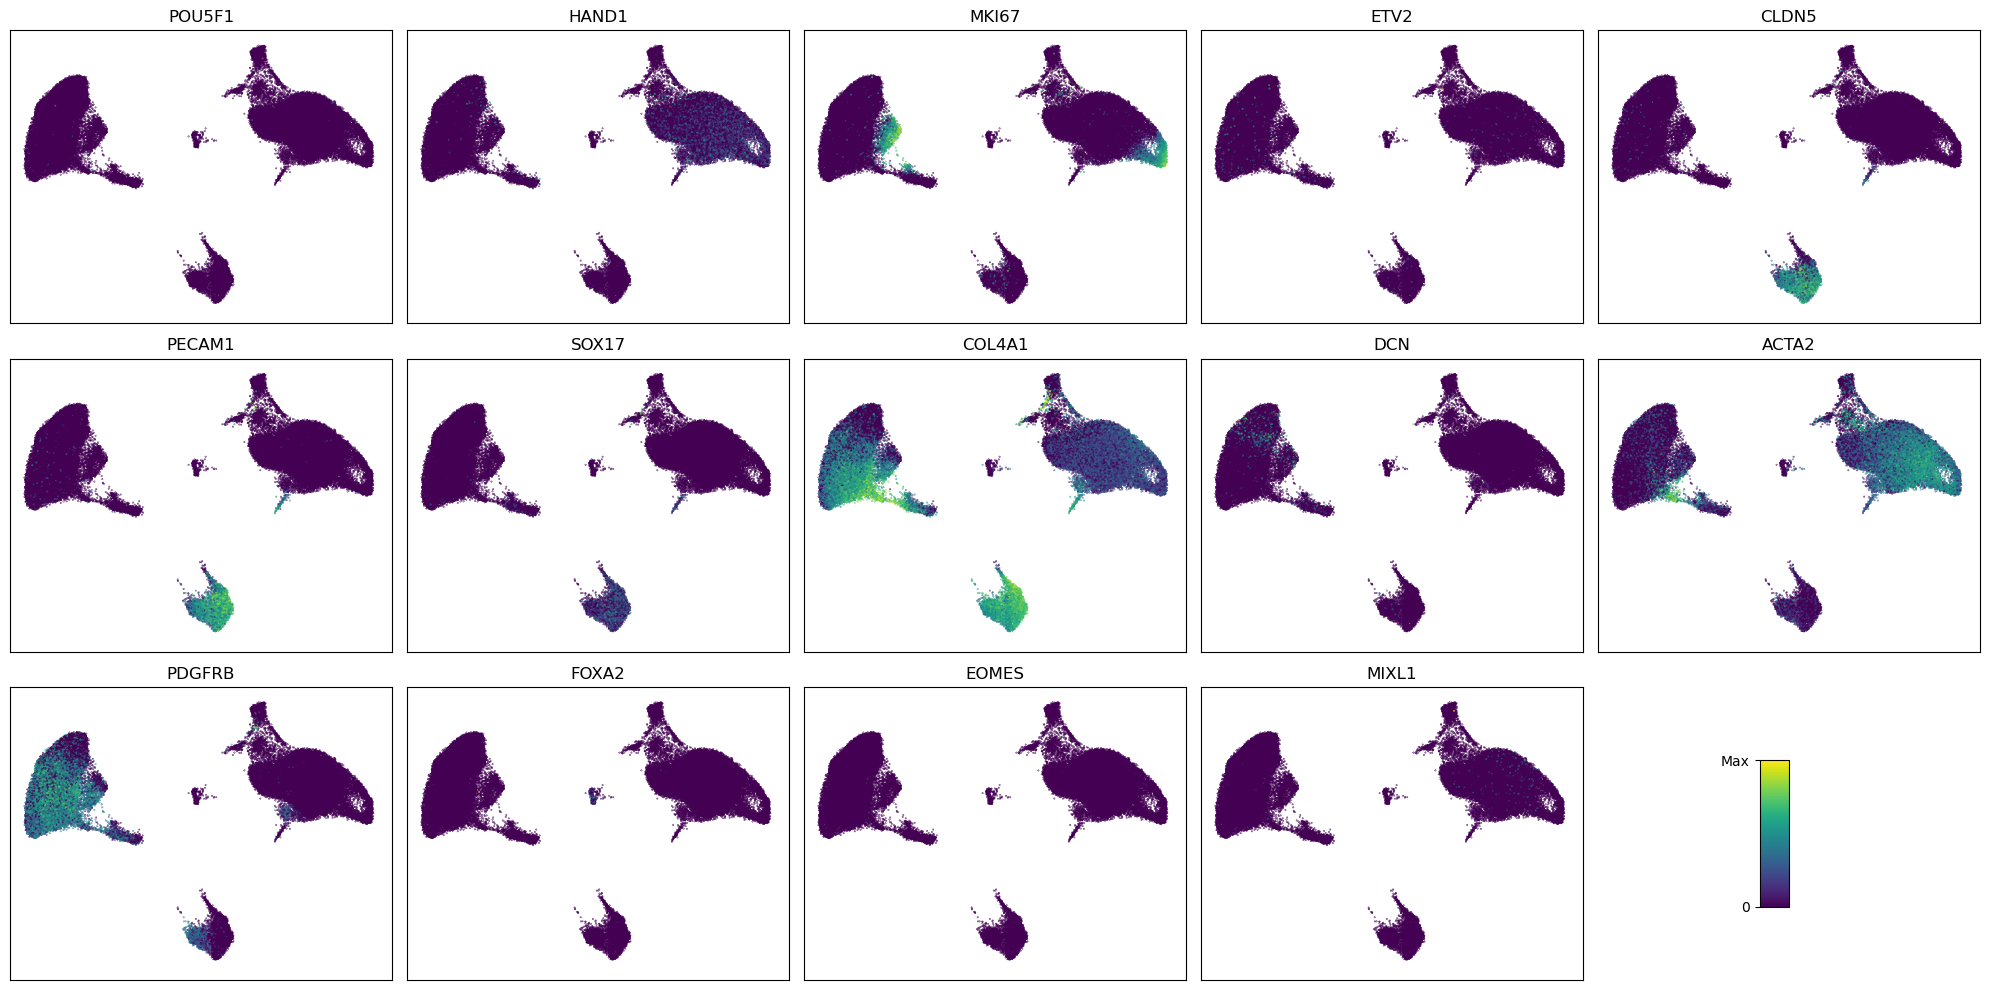

In [68]:
genes = ['POU5F1', 'HAND1', 'MKI67', 'ETV2', 'CLDN5', 'PECAM1', 'SOX17', 'COL4A1', 'DCN', 'ACTA2', 'PDGFRB', 'FOXA2', 'EOMES', 'MIXL1']

fig, axs = plt.subplots(3, 5, figsize=(20, 10))
axs = axs.flatten()

for i in range(0, len(genes)):
    g = genes[i]
    el = adata_all.X[:, np.where(adata_all.var.index == g)[0][0]]
    alpha = (el / np.max(el)).toarray().tolist()
    
    ax = axs[i]
    # ax.scatter(adata_all.obsm["X_umap"][:,0], adata_all.obsm["X_umap"][:,1], c="silver", s=0.3, alpha=1)
    # ax.scatter(adata_all.obsm["X_umap"][:,0], adata_all.obsm["X_umap"][:,1], c="steelblue", s=0.3, alpha=alpha)
    ax.scatter(adata_all.obsm["X_umap"][:,0], adata_all.obsm["X_umap"][:,1], c=alpha, s=0.1, alpha=1)
    ax.set_xlim([-11, 20])
    ax.set_ylim([-6, 18])
    ax.set_title(g)
    ax.set_xticks([])
    ax.set_yticks([])

ax = axs[-1]
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.5,
    shrink=0.5, 
    location="left", aspect=5
)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0", "Max"])
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/umap/key_genes/multiple.png")
plt.savefig(f"{WORK_DIR}/umap/key_genes/multiple.svg")
plt.show()

In [69]:
genes = ['TNNT2', 'PECAM1', 'PDGFRB', 'MYH11', 'PDGFRA', 'PENK', 'COL1A1', 'AFP']

for i in range(0, len(genes)):
    g = genes[i]
    fig, axs = plt.subplots(2, 3, figsize=(12, 7))
    # fig.suptitle(g)
    axs = axs.flatten()

    for j, sample in enumerate(samples):
        if sample == "ALL":
            adata = adata_all
        else:
            adata = adata_all[adata_all.obs['batch'] == sample]
        el = adata.X[:, np.where(adata.var.index == g)[0][0]]
        alpha = (el / np.max(el)).toarray().tolist()
    
        ax = axs[j]
        # ax.scatter(adata.obsm["X_umap"][:,0], adata.obsm["X_umap"][:,1], c="silver", s=0.3, alpha=1)
        # ax.scatter(adata.obsm["X_umap"][:,0], adata.obsm["X_umap"][:,1], c="steelblue", s=0.3, alpha=alpha.toarray().tolist())
        ax.scatter(adata.obsm["X_umap"][:,0], adata.obsm["X_umap"][:,1], c=alpha, s=0.1, alpha=1)
        ax.set_xlim([-11, 20])
        ax.set_ylim([-6, 18])
        ax.set_title(sample)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(f"{WORK_DIR}/umap/key_genes/{g}.png")
    plt.savefig(f"{WORK_DIR}/umap/key_genes/{g}.svg")
    plt.close()

# 2. Celltype subcluster

In [23]:
os.system(f"mkdir -p {WORK_DIR}/adata/cell_type_subclustered")

0

## 2.1 CM

In [8]:
ct = "CM"
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.5, random_state=42)
# sc.pl.umap(adata, color="cell_type_subcluster")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [9]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

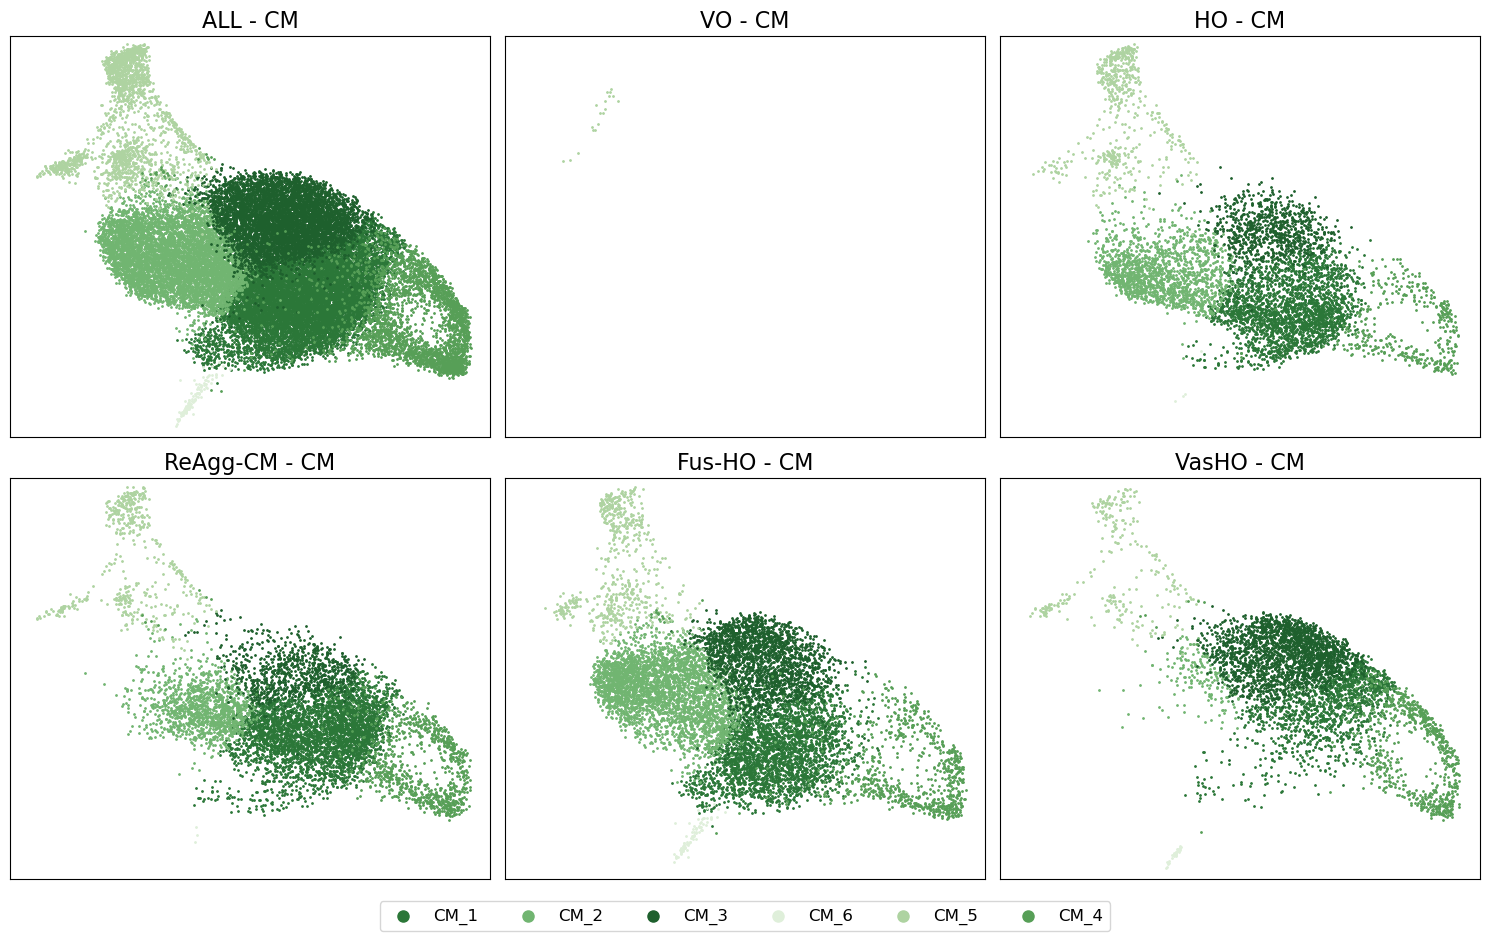

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([6, 19])
    ax.set_ylim([5, 17])
    ax.set_title(f"{sample} - {ct}", fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=6,
    markerscale=8,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umap/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umap/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

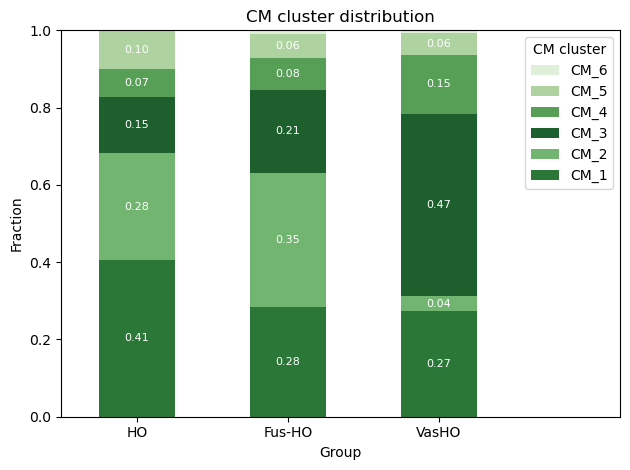

In [11]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'ReAgg-CM' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

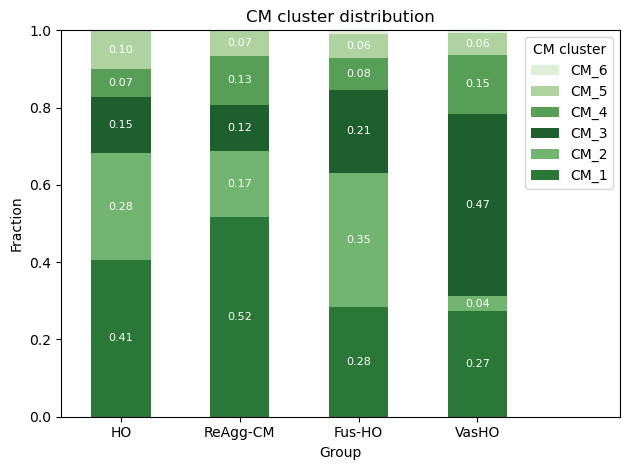

In [12]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[colormap_subclusters[col] for col in df.columns])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distribution/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

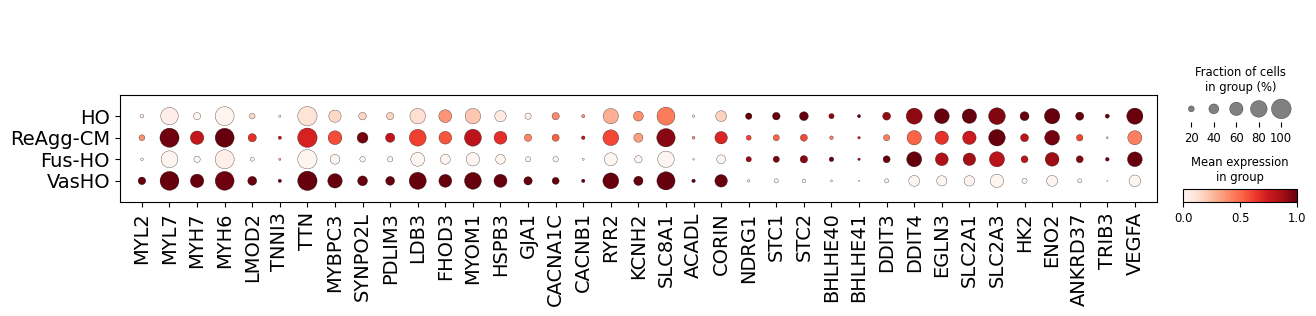

In [13]:
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SLC8A1', 
               'ACADL', 'CORIN'] + ['NDRG1', 'STC1', 'STC2', 'BHLHE40', 'BHLHE41', 'DDIT3', 'DDIT4', 'EGLN3', 'SLC2A1', 'SLC2A3', 'HK2', 'ENO2', 'ANKRD37', 'TRIB3', 'VEGFA']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("VO")

dp = sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

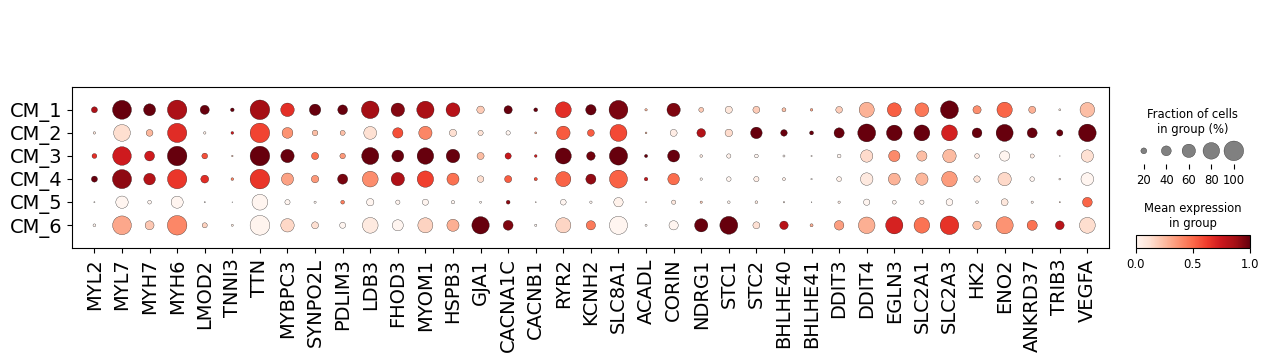

In [14]:
marker_dict = ['MYL2', 'MYL7', 'MYH7', 'MYH6', 'LMOD2', 'TNNI3', 'TTN', 'MYBPC3', 
               'SYNPO2L', 'PDLIM3', 'LDB3', 'FHOD3', 'MYOM1','HSPB3', 
               'GJA1', 'CACNA1C', 'CACNB1', 'RYR2', 'KCNH2', 'SLC8A1', 
               'ACADL', 'CORIN'] + ['NDRG1', 'STC1', 'STC2', 'BHLHE40', 'BHLHE41', 'DDIT3', 'DDIT4', 'EGLN3', 'SLC2A1', 'SLC2A3', 'HK2', 'ENO2', 'ANKRD37', 'TRIB3', 'VEGFA']

dp = sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

In [15]:
# marker_dict = ['NDRG1', 'STC1', 'STC2', 'BHLHE40', 'BHLHE41', 'DDIT3', 'DDIT4', 'EGLN3', 'SLC2A1', 'SLC2A3', 'HK2', 'ENO2', 'ANKRD37', 'TRIB3', 'VEGFA']
# categories_order = samples.copy()
# categories_order.remove("ALL")
# categories_order.remove("VO")

# dp = sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
# dp.make_figure()
# ax = dp.ax_dict["mainplot_ax"]
# ax.tick_params(axis="x", labelsize=14)
# ax.tick_params(axis="y", labelsize=14)

# plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.new.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.new.svg', bbox_inches="tight")
# plt.show()

## 2.2 EC

In [5]:
ct = "EC"
# adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.3, random_state=42)
# sc.pl.umap(adata, color="leiden")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [6]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

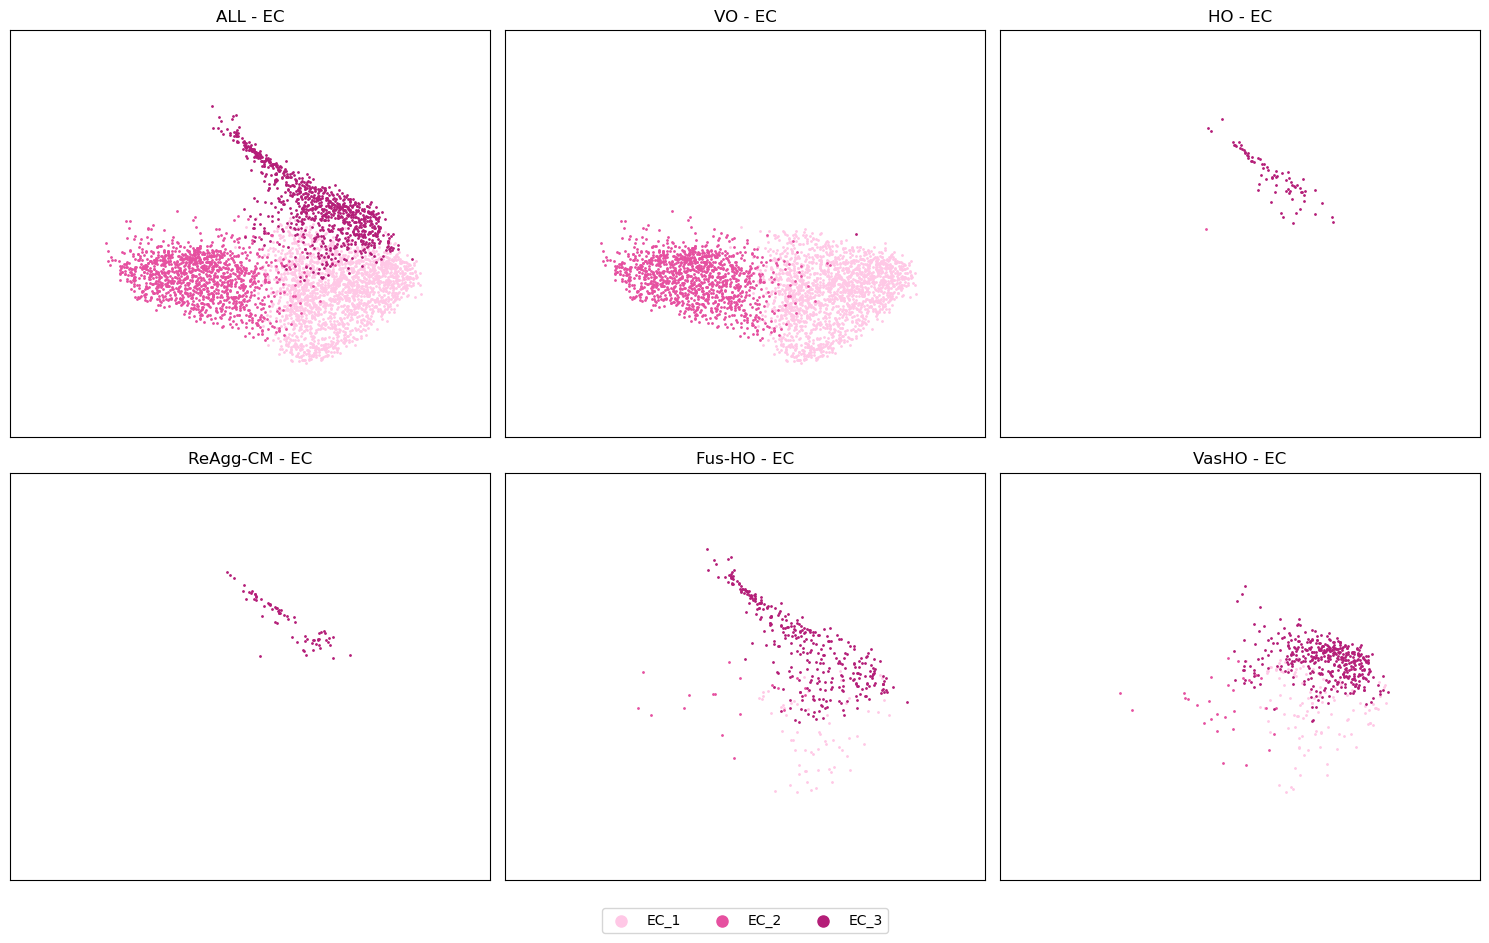

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1, color=colormap_subclusters[ctsc])
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([2, 8])
    ax.set_ylim([-6, 3])
    ax.set_title(f"{sample} - {ct}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, 
    labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umap/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umap/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


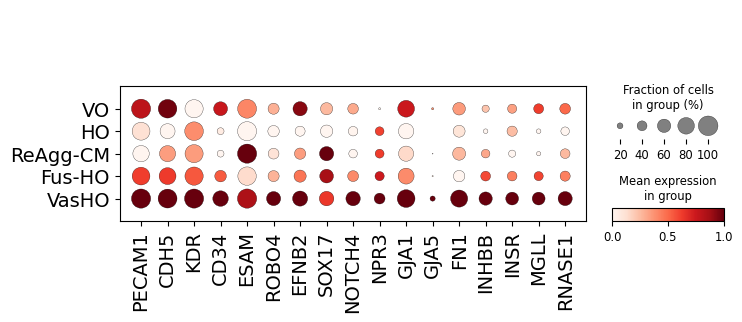

In [7]:
marker_dict = ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1']

categories_order = samples.copy()
categories_order.remove("ALL")

dp = sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


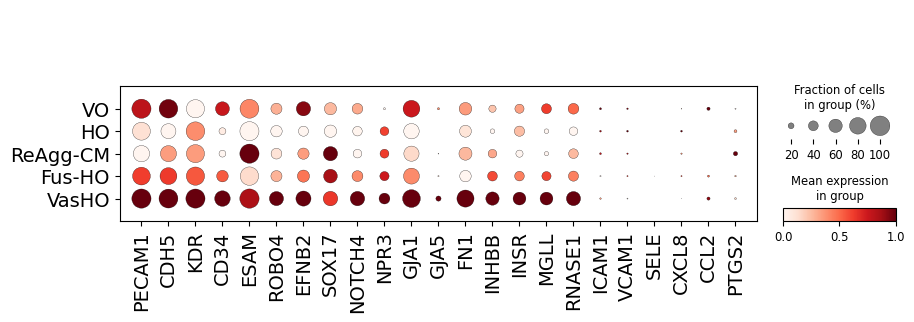

In [8]:
marker_dict = ['PECAM1', 'CDH5', 'KDR', 'CD34', 'ESAM','ROBO4','EFNB2', 'SOX17', 'NOTCH4', 
               'NPR3', 'GJA1','GJA5','FN1', 'INHBB', 'INSR', 'MGLL', 'RNASE1', 'ICAM1', 'VCAM1', 'SELE', 'CXCL8', 'CCL2','PTGS2']

categories_order = samples.copy()
categories_order.remove("ALL")

dp = sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.additional.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.additional.svg', bbox_inches="tight")
plt.show()

## 2.3 CF

In [10]:
ct = "CF"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.5, random_state=42)
# sc.pl.umap(adata, color="cell_type_subcluster")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


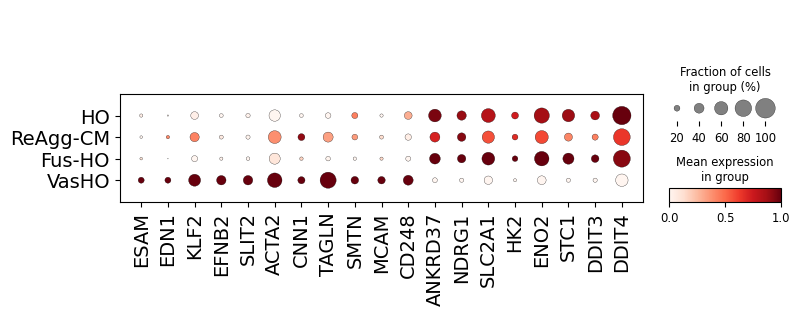

In [11]:
marker_dict = ['ESAM', 'EDN1', 'KLF2', 'EFNB2', 'SLIT2', 'ACTA2', 'CNN1', 'TAGLN', 'SMTN', 'MCAM', 'CD248', 'ANKRD37', 'NDRG1', 'SLC2A1', 'HK2', 'ENO2', 'STC1', 'DDIT3', 'DDIT4']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("VO")

dp = sc.pl.dotplot(adata[adata.obs["batch"] != "VO"], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.4 MP

In [12]:
ct = "MP"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.5, random_state=42)
# sc.pl.umap(adata, color="cell_type_subcluster")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


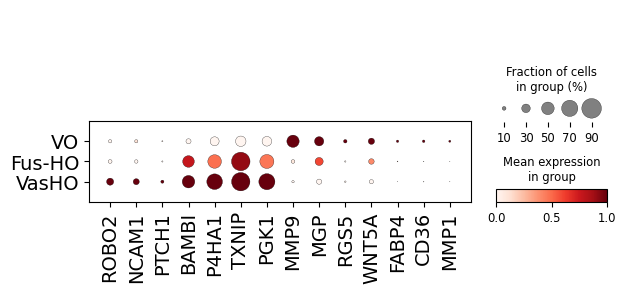

In [13]:
marker_dict = ['ROBO2', 'NCAM1', 'PTCH1', 'BAMBI', 'P4HA1', 'TXNIP', 'PGK1', 'MMP9', 'MGP', 'RGS5', 'WNT5A', 'FABP4', 'CD36', 'MMP1']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("HO")
categories_order.remove("ReAgg-CM")

dp = sc.pl.dotplot(adata[adata.obs["batch"].isin(["VO", "Fus-HO", "VasHO"])], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.5 PC

In [14]:
ct = "PC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.5, random_state=42)
# sc.pl.umap(adata, color="cell_type_subcluster")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


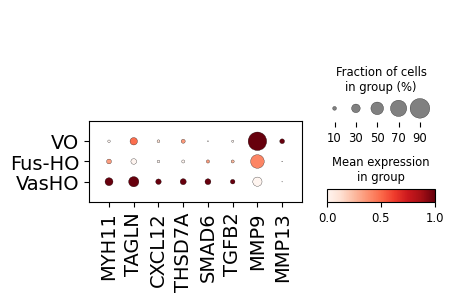

In [15]:
marker_dict = ['MYH11', 'TAGLN', 'CXCL12', 'THSD7A', 'SMAD6', 'TGFB2', 'MMP9', 'MMP13']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("HO")
categories_order.remove("ReAgg-CM")

dp = sc.pl.dotplot(adata[adata.obs["batch"].isin(["VO", "Fus-HO", "VasHO"])], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.6 VSMC

In [5]:
ct = "VSMC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.5, random_state=42)
# sc.pl.umap(adata, color="cell_type_subcluster")

# adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
# adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

# adata.write(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


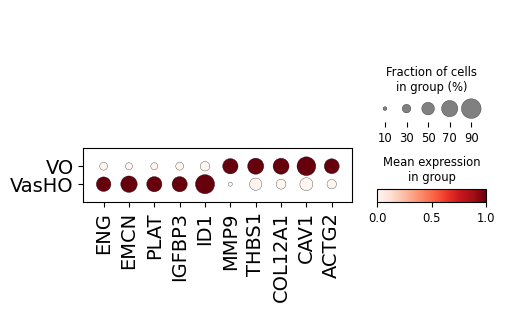

In [6]:
marker_dict = ['ENG', 'EMCN', 'PLAT', 'IGFBP3', 'ID1', 'MMP9', 'THBS1', 'COL12A1', 'CAV1', 'ACTG2']
categories_order = samples.copy()
categories_order.remove("ALL")
categories_order.remove("HO")
categories_order.remove("ReAgg-CM")
categories_order.remove("Fus-HO")

dp = sc.pl.dotplot(adata[adata.obs["batch"].isin(["VO", "VasHO"])], marker_dict, groupby="batch", standard_scale="var", show=False, categories_order=categories_order, return_fig=True)
dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

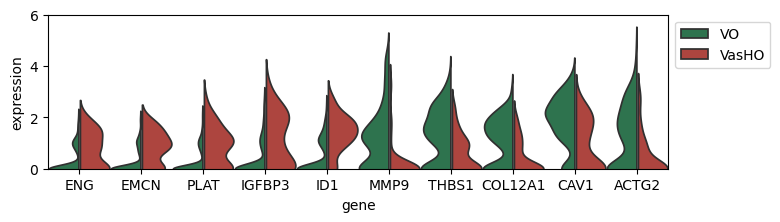

In [11]:
adata_sub = adata[adata.obs["batch"].isin(["VO", "VasHO"])]

plot_df = {"batch": [], "gene": [], "expression": []}

for g in marker_dict:
    plot_df["batch"] = plot_df["batch"] + adata_sub.obs["batch"].to_list()
    plot_df["gene"] = plot_df["gene"] + [g] * adata_sub.n_obs
    plot_df["expression"] = plot_df["expression"] + adata_sub.X[:, adata_sub.var_names == g].toarray().ravel().tolist()

plot_df = pd.DataFrame(plot_df)

fig, ax = plt.subplots(1, 1, figsize=(8, 2))

sns.violinplot(
    ax=ax,
    data=plot_df, 
    x="gene", 
    y="expression", 
    hue="batch", 
    split=True, 
    inner=None,
    density_norm='count',
    width=1,
    gap=.05,
    palette={"VO": "#227f4d", "VasHO": "#c0352c"}
)

ax.set_ylim(0, 6)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.violin.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/by_batch.{ct}.violin.svg', bbox_inches="tight")

plt.show()

# 3. DE

In [25]:
def volcano_plot2(
    adata, 
    label1, 
    label2, 
    title=None, 
    label_type='cell_type_subcluster', 
    keygenes=None, 
    save=None, 
    save_svg=False,
    save_tsv=None,
    fc_thres=1, 
    pvalue_thres=5,
    mean_thres=0,
    scatter_alpha=0.5,
    s_power=0.5,
    s_mean=5,
):
    PSEUDOCOUNT=0.0001
    
    if label1 == "all":
        data1 = adata.X.todense().copy() + PSEUDOCOUNT
    elif label1 == "rest":
        data1 = adata.X[np.where(adata.obs[label_type] != label2)[0], :].todense().copy() + PSEUDOCOUNT
    else:
        data1 = adata.X[np.where(adata.obs[label_type] == label1)[0], :].todense().copy() + PSEUDOCOUNT
        
    if label2 == "all":
        data2 = adata.X.todense().copy() + PSEUDOCOUNT
    elif label2 == "rest":
        data2 = adata.X[np.where(adata.obs[label_type] != label1)[0], :].todense().copy() + PSEUDOCOUNT
    else:
        data2 = adata.X[np.where(adata.obs[label_type] == label2)[0], :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.squeeze(np.asarray(np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )))

    means = np.squeeze(np.asarray(np.mean(np.concatenate((data1, data2), axis=0), axis=0))) - PSEUDOCOUNT
    means_1 = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
    means_2 = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    is_signi_pval = set([i for i in range(0, adata.n_vars) if transformed_pvalues[i] >= pvalue_thres])
    is_signi_fc = set([i for i in range(0, adata.n_vars) if abs(foldchanges[i]) >= fc_thres])
    is_signi_mean = set([i for i in range(0, adata.n_vars) if means_1[i] >= mean_thres or means_2[i] >= mean_thres])
    
    idx_signi = [i for i in range(0, adata.n_vars) if (i in is_signi_pval and i in is_signi_fc and i in is_signi_mean)]
    idx_inc = [i for i in idx_signi if foldchanges[i] > 0]
    idx_dec = [i for i in idx_signi if foldchanges[i] < 0]

    s = (means + PSEUDOCOUNT) ** s_power
    s = s / s.mean() * s_mean

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=scatter_alpha,
                s=s, 
                linewidths=0)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=scatter_alpha,
                s=s[idx_inc], 
                linewidths=0)
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=scatter_alpha,
                s=s[idx_dec], 
                linewidths=0)
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save, bbox_inches="tight")
        if save_svg:
            plt.savefig(save.strip(".png") + ".svg", bbox_inches="tight")
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata.var_names.to_list()
        de_dict['mean'] = means
        de_dict[f'{label1}_mean'] = means_1
        de_dict[f'{label1}_positive_frac'] = np.squeeze(np.asarray(np.mean(data1 > PSEUDOCOUNT, axis=0)))
        de_dict[f'{label2}_mean'] = means_2
        de_dict[f'{label2}_positive_frac'] = np.squeeze(np.asarray(np.mean(data2 > PSEUDOCOUNT, axis=0)))
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['is_significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t', index=False)
        df[df['is_significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t', index=False)

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t', index=False)

In [26]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")

## 3.1 general DEG

In [14]:
os.system(f"rm -r {WORK_DIR}/DE")
os.system(f"mkdir -p {WORK_DIR}/DE")

0

In [27]:
batches = samples.copy()
batches.remove("ALL")

n_cell_min = 30

for ct in tqdm.tqdm(["CM", "PC", "VSMC", "CF", "MP", "EC"]):
    os.system(f"mkdir -p {WORK_DIR}/DE/{ct}")
    adata_sub = adata_all[adata_all.obs["cell_type"] == ct]

    for i in range(0, len(batches)):
        for j in range(i+1, len(batches)):
            batch1 = batches[i]
            batch2 = batches[j]
            
            if (adata_sub.obs["batch"] == batch1).sum() < n_cell_min:
                continue
            if (adata_sub.obs["batch"] == batch2).sum() < n_cell_min:
                continue
                
            volcano_plot2(
                adata=adata_sub, 
                label1=batch1, 
                label2=batch2, 
                title=f"{ct}.{batch1}.{batch2}", 
                label_type='batch', 
                keygenes=None, 
                save=f"{WORK_DIR}/DE/{ct}/{ct}.{batch1}.{batch2}.png", 
                save_tsv=f"{WORK_DIR}/DE/{ct}/{ct}.{batch1}.{batch2}.tsv",
                fc_thres=0.5, 
                pvalue_thres=5
            )

  0%|                                                        | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_3435849/565068757.py:45: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
100%|████████████████████████████████████████████████| 1/1 [00:15<00:00, 15.84s/it]


## 3.2 ligand receptor

In [49]:
os.system(f"rm -r {WORK_DIR}/DE/ligand_receptor")
os.system(f"mkdir -p {WORK_DIR}/DE/ligand_receptor")

0

In [50]:
adata_sub = adata_all[adata_all.obs["batch"] == "VasHO"]
adata_sub = adata_sub[adata_sub.obs["cell_type"] == "CF"]
adata_sub.obs["EDN1"] = (adata_sub.X[:,adata_sub.var_names == "EDN1"] > 0).toarray().ravel()

volcano_plot2(
    adata=adata_sub, 
    label1=True, 
    label2=False, 
    title=f"CF.EDN1.True.False", 
    label_type='EDN1', 
    keygenes=None, 
    save=f"{WORK_DIR}/DE/ligand_receptor/CF.EDN1.True.False.png", 
    save_tsv=f"{WORK_DIR}/DE/ligand_receptor/CF.EDN1.True.False.tsv",
    fc_thres=0.5, 
    pvalue_thres=5,
    s_power=0.75,
)

/tmp/ipykernel_3089700/2631712116.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs["EDN1"] = (adata_sub.X[:,adata_sub.var_names == "EDN1"] > 0).toarray().ravel()
/tmp/ipykernel_3089700/565068757.py:45: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


In [51]:
adata_sub = adata_all[adata_all.obs["batch"] == "VasHO"]
adata_sub = adata_sub[adata_sub.obs["cell_type"] == "CM"]
adata_sub.obs["EDNRA"] = (adata_sub.X[:,adata_sub.var_names == "EDNRA"] > 0).toarray().ravel()

volcano_plot2(
    adata=adata_sub, 
    label1=True, 
    label2=False, 
    title=f"CM.EDNRA.True.False", 
    label_type='EDNRA', 
    keygenes=None, 
    save=f"{WORK_DIR}/DE/ligand_receptor/CM.EDNRA.True.False.png", 
    save_tsv=f"{WORK_DIR}/DE/ligand_receptor/CM.EDNRA.True.False.tsv",
    fc_thres=0.5, 
    pvalue_thres=5,
    s_power=0.75,
)

/tmp/ipykernel_3089700/3958565443.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs["EDNRA"] = (adata_sub.X[:,adata_sub.var_names == "EDNRA"] > 0).toarray().ravel()


In [52]:
ventricular_maturation_sarcomere = ['CACNA1C','CACNB1','FHL1','FHOD3','GJA1','HOPX','HSPB3','KCNH2','LDB3','LMOD2','MYBPC3','MYH6','MYH7','MYL2','MYL7','MYOM1','PDLIM3','RYR2','SCN5A','SLC8A1','SYNPO2L','TNNI3','TTN']

fetal_stress_hypertrophy = ['ACTA1','ANKRD1','CCN1','CCN2','FOS','NMRK2','NPPA','XIRP1']

HIF_hypoxia_targets = ['ADM','ALDOA','ANKRD37','BHLHE40','BHLHE41','BNIP3','DDIT3','DDIT4','EGLN3','ENO2','HILPDA','HK2','LDHA','NDRG1','NDUFA4L2','P4HA1','PDK1','PFKFB3','PFKFB4','PGK1','SLC2A1','SLC2A3','STC1','STC2','TRIB3','TXNIP','VEGFA']

/tmp/ipykernel_3089700/1847163601.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs[goi] = (adata_sub.X[:,adata_sub.var_names == goi] > 0).toarray().ravel()


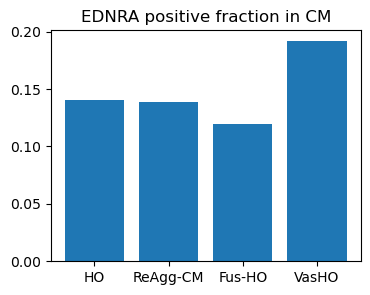

['802/5713', '1016/7312', '1151/9613', '904/4719']


In [53]:
ct = "CM"
goi = "EDNRA"
valid_groups = ("HO", "ReAgg-CM", "Fus-HO", "VasHO")

adata_sub = adata_all[adata_all.obs["cell_type"] == ct]
adata_sub.obs[goi] = (adata_sub.X[:,adata_sub.var_names == goi] > 0).toarray().ravel()

X = []
Y = []
lbl = []

for sample in samples:
    if sample not in valid_groups:
        continue
    adata_ss = adata_sub[adata_sub.obs["batch"] == sample]
    X.append(sample)
    Y.append(np.sum(adata_ss.obs[goi]) / adata_ss.shape[0])
    lbl.append(f"{np.sum(adata_ss.obs[goi])}/{adata_ss.shape[0]}")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(np.arange(0, len(X)), Y)
ax.set_xticks(np.arange(0, len(X)), X)
ax.set_title(f"{goi} positive fraction in {ct}")
plt.savefig(f"{WORK_DIR}/DE/ligand_receptor/frac.{ct}.{goi}.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/DE/ligand_receptor/frac.{ct}.{goi}.svg", bbox_inches="tight")
plt.show()

print(lbl)

/tmp/ipykernel_3089700/2495265684.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs[goi] = (adata_sub.X[:,adata_sub.var_names == goi] > 0).toarray().ravel()


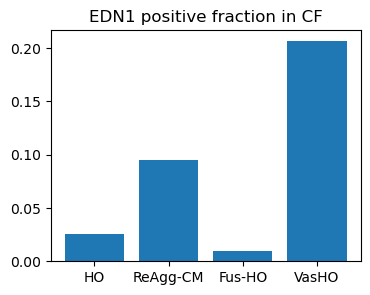

['5/196', '39/409', '3/320', '98/475']


In [54]:
ct = "CF"
goi = "EDN1"
valid_groups = ("HO", "ReAgg-CM", "Fus-HO", "VasHO")

adata_sub = adata_all[adata_all.obs["cell_type"] == ct]
adata_sub.obs[goi] = (adata_sub.X[:,adata_sub.var_names == goi] > 0).toarray().ravel()

X = []
Y = []
lbl = []

for sample in samples:
    if sample not in valid_groups:
        continue
    adata_ss = adata_sub[adata_sub.obs["batch"] == sample]
    X.append(sample)
    Y.append(np.sum(adata_ss.obs[goi]) / adata_ss.shape[0])
    lbl.append(f"{np.sum(adata_ss.obs[goi])}/{adata_ss.shape[0]}")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(np.arange(0, len(X)), Y)
ax.set_xticks(np.arange(0, len(X)), X)
ax.set_title(f"{goi} positive fraction in {ct}")
plt.savefig(f"{WORK_DIR}/DE/ligand_receptor/frac.{ct}.{goi}.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/DE/ligand_receptor/frac.{ct}.{goi}.svg", bbox_inches="tight")
plt.show()

print(lbl)

/tmp/ipykernel_3089700/1242524131.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs[goi] = (adata_sub.X[:,adata_sub.var_names == goi] > 0).toarray().ravel()


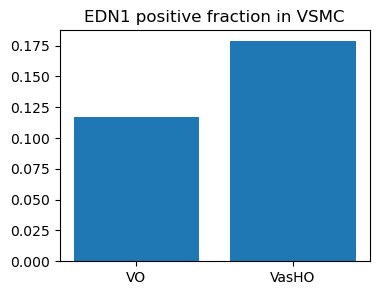

['37/317', '10/56']


In [55]:
ct = "VSMC"
goi = "EDN1"
valid_groups = ("VO", "VasHO")

adata_sub = adata_all[adata_all.obs["cell_type"] == ct]
adata_sub.obs[goi] = (adata_sub.X[:,adata_sub.var_names == goi] > 0).toarray().ravel()

X = []
Y = []
lbl = []

for sample in samples:
    if sample not in valid_groups:
        continue
    adata_ss = adata_sub[adata_sub.obs["batch"] == sample]
    X.append(sample)
    Y.append(np.sum(adata_ss.obs[goi]) / adata_ss.shape[0])
    lbl.append(f"{np.sum(adata_ss.obs[goi])}/{adata_ss.shape[0]}")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(np.arange(0, len(X)), Y)
ax.set_xticks(np.arange(0, len(X)), X)
ax.set_title(f"{goi} positive fraction in {ct}")
plt.savefig(f"{WORK_DIR}/DE/ligand_receptor/frac.{ct}.{goi}.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/DE/ligand_receptor/frac.{ct}.{goi}.svg", bbox_inches="tight")
plt.show()

print(lbl)

## 3.3 subclusters

In [23]:
ct = "CM"

os.system(f"rm -r {WORK_DIR}/DE/{ct}_subcluster; mkdir -p {WORK_DIR}/DE/{ct}_subcluster")

adata_cm = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

batches = list(adata_cm.obs["cell_type_subcluster"].value_counts().index)

for i in range(0, len(batches)):
    for j in range(i+1, len(batches)):
        batch1 = batches[i]
        batch2 = batches[j]
            
        volcano_plot2(
            adata=adata_cm, 
            label1=batch1, 
            label2=batch2, 
            title=f"{ct}.{batch1}.{batch2}", 
            label_type='cell_type_subcluster', 
            keygenes=None, 
            save=f"{WORK_DIR}/DE/{ct}_subcluster/{ct}.{batch1}.{batch2}.png", 
            save_tsv=f"{WORK_DIR}/DE/{ct}_subcluster/{ct}.{batch1}.{batch2}.tsv",
            fc_thres=0.5, 
            pvalue_thres=5
        )

/tmp/ipykernel_3435849/565068757.py:45: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


In [24]:
ct = "EC"

os.system(f"mkdir -p {WORK_DIR}/DE/{ct}_subcluster")

adata_cm = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

batches = list(adata_cm.obs["cell_type_subcluster"].value_counts().index)

for i in range(0, len(batches)):
    for j in range(i+1, len(batches)):
        batch1 = batches[i]
        batch2 = batches[j]
            
        volcano_plot2(
            adata=adata_cm, 
            label1=batch1, 
            label2=batch2, 
            title=f"{ct}.{batch1}.{batch2}", 
            label_type='cell_type_subcluster', 
            keygenes=None, 
            save=f"{WORK_DIR}/DE/{ct}_subcluster/{ct}.{batch1}.{batch2}.png", 
            save_tsv=f"{WORK_DIR}/DE/{ct}_subcluster/{ct}.{batch1}.{batch2}.tsv",
            fc_thres=0.5, 
            pvalue_thres=5
        )

# 4. scVelo

In [13]:
os.system(f"qsub {WORK_DIR}/scVelo/scVelo_job.sh")

requested Hard Resources
  memory (s_vmem): 128G = The job requires 128GB of memory per slot.
  slots (def_slot): 1 = The job requires 100% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 124609486 ("scVelo_job.sh") has been submitted


0

# 5. CPDB

In [2]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import ktplotspy as kpy
import seaborn as sns
import matplotlib.pyplot as plt

import glob
from tqdm import tqdm

from cellphonedb.src.core.methods import cpdb_analysis_method,cpdb_statistical_analysis_method

In [3]:
base_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO12"

cpdb_path = "/home/brett/work/Cell2CellCommunication/cpdb/database/v5.0.0/cellphonedb.zip"
work_dir  = f"{base_dir}/cpdb"
data_dir  = f"{base_dir}/cpdb/adata"
processed_dir = f"{base_dir}/cpdb/processed"
figs_dir = f"{base_dir}/cpdb/figs"

In [4]:
os.system(f"mkdir -p {data_dir}; mkdir -p {processed_dir}; mkdir -p {figs_dir}")

0

In [5]:
valid_cts = {
    "VO": ["PC", "EC", "MP", "VSMC"],
    "HO": ["CM", "EC", "CF", "OTH"],
    "ReAgg-CM": ["CM", "EC", "CF", "OTH"],
    "Fus-HO": ["CM", "PC", "EC", "MP", "CF", "OTH"],
    "VasHO": ["CM", "PC", "EC", "MP", "CF", "VSMC", "OTH"],
}

adata_full = sc.read_h5ad(f"{base_dir}/adata/cell_type_labelled/ALL.h5ad")
adata_full.obs["cpdb_group"] = adata_full.obs["cell_type"].copy()
sc.pp.highly_variable_genes(adata_full, n_top_genes=4000)

for batch in adata_full.obs["batch"].unique():
    adata_sub = adata_full[adata_full.obs['batch'] == batch]
    adata_sub = adata_sub[adata_sub.obs["cpdb_group"].isin(valid_cts[batch])]
    adata_sub.write(f"{work_dir}/adata/{batch}.h5ad")

## RUN

In [6]:
pattern = os.path.join(data_dir,"*.h5ad")
for adata_path in glob.glob(pattern):
    # if ("/HO.h5ad" not in adata_path) and ("/VCO.h5ad" not in adata_path):
    #     continue
    print(adata_path)

    label = os.path.basename(adata_path).split(".")[0]
    adata = sc.read_h5ad(adata_path)
    adata = adata[:,adata.var['highly_variable']]
    updated_adata_path = os.path.join(processed_dir,os.path.basename(adata_path.replace(".h5ad",".hvg.h5ad")))
    adata.write(updated_adata_path,compression="gzip")

    metadata_df = pd.DataFrame({
        "barcode_sample" : adata.obs_names,
        "cell_type"      : adata.obs['cpdb_group'].to_list()
    })

    metadata_df.index = np.arange(metadata_df.shape[0])
    metadata_path     = os.path.join(work_dir,f"{label}.statistical.metadata.tsv")
    metadata_df.to_csv(metadata_path,index=False,sep="\t")

    out_dir      = os.path.join(work_dir,f"{label}.statistical")
    # Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
    cpdb_results = cpdb_statistical_analysis_method.call(
        cpdb_file_path     = cpdb_path,         # mandatory: CellphoneDB database zip file.
        meta_file_path     = metadata_path,     # mandatory: tsv file defining barcodes to cell label.
        counts_file_path   = updated_adata_path,# mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
        counts_data        = 'gene_name',       # defines the gene annotation in counts matrix.
        score_interactions = True,              # optional: whether to score interactions or not. 
        output_path        = out_dir,           # Path to save results
        pvalue             = 0.05
    )

/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/adata/VO.h5ad
Reading user files...
The following user files were loaded successfully:
/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/processed/VO.hvg.h5ad
/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/VO.statistical.metadata.tsv
[ ][CORE][25/07/26-09:24:22][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
[ ][CORE][25/07/26-09:24:34][INFO] Running Real Analysis
[ ][CORE][25/07/26-09:24:34][INFO] Running Statistical Analysis


100%|███████████████████████████████████████| 1000/1000 [00:24<00:00, 40.32it/s]

[ ][CORE][25/07/26-09:24:59][INFO] Building Pvalues result
[ ][CORE][25/07/26-09:24:59][INFO] Building results


[ ][CORE][25/07/26-09:24:59][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 63.03it/s]

...

[ ][CORE][25/07/26-09:26:25][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|████████████████████████████████████████████| 6/6 [00:00<00:00, 304.56it/s]

[ ][CORE][25/07/26-09:26:26][INFO] Scoring interactions: Calculating scores for all interactions and cell types..



100%|██████████████████████████████████████████| 36/36 [00:00<00:00, 146.91it/s]

Saved deconvoluted to /home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical/statistical_analysis_deconvoluted_07_25_2026_092626.txt
Saved deconvoluted_percents to /home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical/statistical_analysis_deconvoluted_percents_07_25_2026_092626.txt
Saved means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical/statistical_analysis_means_07_25_2026_092626.txt
Saved pvalues to /home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical/statistical_analysis_pvalues_07_25_2026_092626.txt
Saved significant_means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical/statistical_analysis_significant_means_07_25_2026_092626.txt
Saved interaction_scores to /home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical/statistical_analysis_interaction_scores_07_25_2026_092626.txt


In [7]:
pattern = os.path.join(work_dir,"*.statistical")
date = "07_25_2026"
for cpdb_dir in glob.glob(pattern):
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_path         = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_means_{date}_*.txt"))[0]
    pvals_path         = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_pvalues_{date}_*.txt"))[0]
    deconvolution_path = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_deconvoluted_{date}_*.txt"))[0]
    interaction_path   = glob.glob(os.path.join(cpdb_dir,f"statistical_analysis_interaction_scores_{date}_*.txt"))[0]

    means_df         = pd.read_csv(means_path,sep="\t")
    pvals_df         = pd.read_csv(pvals_path,sep="\t")
    deconvolution_df = pd.read_csv(deconvolution_path,sep="\t")
    interaction_df   = pd.read_csv(interaction_path,sep="\t")

    adata_path = os.path.join(data_dir,f"{label}.h5ad")
    adata      = ad.read_h5ad(adata_path)
    adata.obs["cpdb_key"] = adata.obs["cpdb_group"]

    for cpdb_key in tqdm(adata.obs["cpdb_key"].unique(),desc=label):
        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=cpdb_key,
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key="cpdb_key",
            highlight_size=1,
            figsize=(24,24),
            title=f"{label} {cpdb_key}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df_path = os.path.join(cpdb_dir,f"{label}__{cpdb_key}.csv")
        df.to_csv(df_path)

ReAgg-CM: 100%|███████████████████████████████████| 4/4 [00:01<00:00,  3.62it/s]


In [8]:
from plotnine import scale_color_identity, scale_fill_identity
from plotnine import scale_color_manual
import plotnine
from matplotlib.legend import Legend
    
pattern = os.path.join(work_dir, "*.statistical")
date = "07_25_2026"

for cpdb_dir in glob.glob(pattern):
    print(cpdb_dir)
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
    pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
    decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
    adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

    out = kpy.plot_cpdb_heatmap(
        pvals=pvals_df,
        symmetrical=False,
        return_tables=True
    )

    g = sns.clustermap(out["count_network"],annot=True,fmt='g',cbar=False,figsize=(6,6),cbar_pos=None,)
    g.ax_col_dendrogram.remove()
    g.ax_heatmap.set_title(f"Number of significant interactions: {label}")
    plt.savefig(f"{figs_dir}/{label}.n_signif_interactions_heatmap.png")
    plt.savefig(f"{figs_dir}/{label}.n_signif_interactions_heatmap.svg")
    plt.close()

    df = kpy.plot_cpdb(
        adata=adata[adata.obs["cpdb_group"] != "OTH"],
        cell_type1=".",
        cell_type2=".",
        means=means_df,
        pvals=pvals_df,
        celltype_key="cpdb_group",
        highlight_size=1,
        figsize=(6,6),
        title=f"{label}",
        default_style=False,
        return_table=True
    )
    df.index = [index.replace(">@<","-") for index in df.index]
    df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
    df["significant"] = df["significant"].fillna("no")
    df = df[df["significant"] == "yes"]
    df_path = f"{figs_dir}/{label}.csv"
    df.to_csv(df_path)

    p = kpy.plot_cpdb(
        adata=adata[adata.obs["cpdb_group"] != "OTH"],
        cell_type1=".",
        cell_type2=".",
        keep_significant_only=True,
        means=means_df,
        pvals=pvals_df,
        celltype_key="cpdb_group",
        figsize=(20, 8),
        title=f"{label}: active interactions",
        return_table=False
    )
    p = p + plotnine.theme(
        axis_text_x=plotnine.element_text(size=18, ha="center"),
        axis_text_y=plotnine.element_text(size=14),
    )
    p.save(f"{figs_dir}/{label}.dotplot.png")
    p.save(f"{figs_dir}/{label}.dotplot.svg")

    cts = adata.obs["cpdb_group"].unique().to_list()
    if "OTH" in cts:
        cts.remove("OTH")
    # if np.nan in cts:
    #     cts.remove(np.nan)

    sector_colors = {
        "CM": (43/255, 119/255, 56/255),
        "EC": (231/255, 76/255, 60/255),
        "MP": (255/255, 240/255, 178/255),
        "PC": (218/255, 150/255, 18/255),
        "CF": (142/255, 150/255, 45/255),
        "VSMC": (165/255, 125/255, 8/255),
        "OTH": (191/255, 200/255, 201/255),
        # "PC+VSMC": (165/255, 125/255, 8/255),
    }

    p = kpy.plot_cpdb_chord(
        adata=adata[adata.obs["cpdb_group"] != "OTH"],
        cell_type1='.',
        cell_type2='.',
        keep_celltypes=cts,
        means=means_df,
        pvals=pvals_df,
        deconvoluted=decon_df,
        celltype_key="cpdb_group",
        # link_kwargs={"direction": 1, "allow_twist": True, "r1": 93, "r2": 93},
        link_kwargs={"direction": 1, "allow_twist": True},
        # sector_text_kwargs={"color": "black", "size": 20, "r": 100, "adjust_rotation": True, "fontweight": "bold"},
        legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
        # sector_radius_limit=(93, 107),
        link_offset=1,
        sector_colors=sector_colors,
    )

    leg = p.ax.get_legend()
    if leg is not None:
        leg.set_visible(False)
                
    plt.savefig(f"{figs_dir}/{label}.chordplot.png")
    plt.savefig(f"{figs_dir}/{label}.chordplot.svg")
    plt.close()

/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/VasHO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/VO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/HO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/Fus-HO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO12/cpdb/ReAgg-CM.statistical
